<a href="https://colab.research.google.com/github/MInesGomes/DataScienceObesityLevels/blob/main/Group02_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id='toc'></a>

### Table of Contents
* [0. Identify Business needs](#business)<br>
* [1. Import Data](#import) <br>
* [2. Explore Data](#explore) <br>
    * [2.1. Basic Exploration](#basic)<br>
    * [2.2. Visualizations functions](#visual_fun)<br>
    * [2.3. Possible inconsistencies](#incons)<br>
    * [2.4. Statistical Exploration](#stats)<br>
        * [2.4.1. Numerical Variables](#stats_num)<br>
        * [2.4.2. Categorical Variables](#stats_cat)<br>
        * [2.4.3. Skewness and Kurtosis](#skew)<br>
        * [2.4.4. Remaining Categorical Variables](#cat)<br>
        * [2.4.5. Target variable](#target)<br>
    * [2.5. Visual Exploration](#visual)<br>
        * [2.5.1. Numerical Variables](#visual_num)<br>
        * [2.5.2. Categorical Variables](#visual_cat)<br>
    * [2.4. In-depth Exploration](#depth)<br>
* [3. Preprocess Data](#preprocess) <br>
    * [3.1. Data Cleaning](#clean)<br>
        * [3.1.1. Outliers](#outliers)<br>
        * [3.1.2. Missing Values](#missing)<br>
    * [3.2. Data Transformation](#transform)<br>
        * [3.2.1. Create new variables](#new)<br>
        * [3.2.2. Misclassifications](#misc)<br>
        * [3.2.3. Incoherencies](#inco)<br>
        * [3.2.4. Binning](#bin)<br>
        * [3.2.5. Reclassify](#rec)<br>
        * [3.2.6. Power Transform](#power)<br>
        * [3.2.7. Apply ordinal encoding and create Dummy variables](#dummy)<br>
        * [3.2.8. Scaling](#scale)<br>

<div class="alert alert-block alert-success">
<a id='business'>
<font color = '#006400'>
    
# 0. Identify Business needs </font>
</a>

Obesity has become one of the most significant global public health challenges of the 21st century.
According to the World Health Organization (WHO), obesity is associated with numerous health
risks including cardiovascular diseases, diabetes, and reduced life expectancy. Understanding the
behavioral, dietary, and physical factors associated with obesity is therefore critical for designing
effective public health policies.

With the increasing availability of lifestyle and health-related data, machine learning provides
powerful tools to identify patterns and relationships between daily habits and obesity levels. By
analyzing factors such as eating behaviors, physical activity, technology use, and demographic
characteristics, data-driven models can uncover meaningful insights into obesity risk factors.

**The goal is to develop a strong understanding of how lifestyle behaviors relate to obesity levels.**

* The objective is to explore the dataset, identify meaningful behavioral patterns, and develop machine learning models capable of predicting obesity levels.

* Develop classification models to predict obesity levels based on lifestyle variables.

* analyze:
    * Which features are the most important predictors of obesity
    * Which behaviors appear to increase or decrease obesity risk
* Propose recommendations for public health policies,
lifestyle interventions, or awareness strategies.


Backup Repository:
https://github.com/MInesGomes/DataScienceObesityLevels/commits/main/DSGroup2.ipynb
    
</div>



[BACK TO TOC](#toc)
    
<div class="alert alert-block alert-success">
<a id='import'>
<font color = '#006400'>
    
# 1. Import Data </font>
</a>

**Importing dataset from github repository**
https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv
    
</div>



In [1]:
import pandas as pd
import numpy as np

# df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')
github_url = 'https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(github_url)

print("\nDataset info:")
print(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


[BACK TO TOC](#toc)
    
<div class="alert alert-block alert-success">
<a id='explore'>
<font color = '#006400'>
    
# 2. Explore Data </font>
</a>

**Exploring Dataset, identifying possible problems and errors, identifying outliers and getting major insights**
    
</div>
    

<div class="alert alert-block alert-warning">

<a id='basic'></a>

## 2.1. Basic Exploration
    
</div>

 The dataset contains 2111 entries and 17 columns. (8 numeric, 9 categorical)

 There are no missing values in any of the columns, as indicated by the 'Non-Null Count'.

 Is also difficult to find duplicates due to inexistence of person unique identifier.

**Columns datatypes (and name changes for clear understanding ):**
* **Numeric:**
  * Age
  * Height
  * Weigh
  * FreVeg (FCVC) - Frequency of vegetable consumption during meals
  * NumMeals (NCP) - Number of main meals consumed daily
  * WaterCons (CH2O) - Amount of water consumed daily
  * FrePhyAc (FAF) - Frequency of physical activity
  * TimeUseTech (TUE) - Time spent using technological devices (e.g., smartphone, computer, television, videogames)
   
* **Categorical binary  (We'l set value 1 if)**:
  * Gender -  Male
  * FamHist -   has a family history with overweight
  * FreHighCal (FAVC) -  the individual frequently consumes high-calorie food
  * Smoke (SMOKE) - the individual smokes
  * MonitorDailyCal (SCC) - the individual monitors daily calorie intake

* **Categorical:**
  * FreBetweenMeals (CAEC) - Frequency of food consumption between meals
  * FreAlcCons (CALC) - Frequency of alcohol consumption
  * MTransp (MTRANS) - Primary mode of transportation used
* **Categorical ordinal**:  TargetObesityL (NObeyesdad )



In [2]:
# Renaming the columns for clear understanding
df = df.rename(columns={'FCVC': 'FreVeg'})
df = df.rename(columns={'NCP': 'NumMeals'})
df = df.rename(columns={'CH2O': 'WaterCons'})
df = df.rename(columns={'FAF': 'FrePhyAc'})
df = df.rename(columns={'TUE': 'TimeUseTech'})
df = df.rename(columns={'family_history_with_overweight': 'FamHist'})
df = df.rename(columns={'FAVC': 'FreHighCal'})
df = df.rename(columns={'SMOKE': 'Smoke'})
df = df.rename(columns={'SCC': 'MonitorDailyCal'})
df = df.rename(columns={'CAEC': 'FreBeweenMeals'})
df = df.rename(columns={'CALC': 'FreAlcCons'})
df = df.rename(columns={'MTRANS': 'MTransp'})
display(df.columns)


Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBeweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'NObeyesdad'],
      dtype='object')

In [3]:
# Creating a dictionary of the variables to plot the description
variable_description = dict( [
    ("FreVeg", "Frequency of vegetable consumption during meals"),
    ("NumMeals", "Number of main meals consumed daily"),
    ("WaterCons", "Amount of water consumed daily"),
    ("FrePhyAc", "Frequency of physical activity"),
    ("TimeUseTech", "Time spent using technological devices"),
    ("FamHist", "has a family history with overweight"),
    ("FreHighCal", "the individual frequently consumes high-calorie food"),
    ("Smoke", "the individual smokes"),
    ("MonitorDailyCal", "the individual monitors daily calorie intake"),
    ("FreBetweenMeals", "Frequency of food consumption between meals"),
    ("FreAlcCons", "Frequency of alcohol consumption"),
    ("MTransp", "Primary mode of transportation used")
])

print(variable_description)


{'FreVeg': 'Frequency of vegetable consumption during meals', 'NumMeals': 'Number of main meals consumed daily', 'WaterCons': 'Amount of water consumed daily', 'FrePhyAc': 'Frequency of physical activity', 'TimeUseTech': 'Time spent using technological devices', 'FamHist': 'has a family history with overweight', 'FreHighCal': 'the individual frequently consumes high-calorie food', 'Smoke': 'the individual smokes', 'MonitorDailyCal': 'the individual monitors daily calorie intake', 'FreBetweenMeals': 'Frequency of food consumption between meals', 'FreAlcCons': 'Frequency of alcohol consumption', 'MTransp': 'Primary mode of transportation used'}


<div class="alert alert-block alert-warning">

<a id='visual_fun'></a>

## 2.2. Visualizations functions
    
</div>

Function to plot an Histograms from the dataset df_plot in `num_cols` columns

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

HIST_PLOT ='Histograms'
BOX_PLOT= 'Box Plot'
# Function to plot a type of chart from the dataset df_plot in `num_cols` columns
def numericColumnsPlot(df_plot,num_cols = 3, type= HIST_PLOT):
  df_plot_desc= df_plot.rename(columns=variable_description)
  numericCols = df_plot_desc.columns[df_plot_desc.dtypes != 'object'].tolist()
  # Exclude target variable if it's numerical and we don't want to plot it here
  if 'TargetObesityL' in numericCols:
      numericCols.remove('TargetObesityL')
  if 'NObeyesdad' in numericCols:
      numericCols.remove('NObeyesdad')

  # Calculate the number of rows and columns needed for the subplots
  num_plots = len(numericCols)
  # num_cols = 3 # Desired number of columns for the plots
  num_rows = math.ceil(num_plots / num_cols)

  # Create subplots dynamically based on the number of numerical columns
  fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
  axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

  # Plot histograms for each numerical column
  for i, col in enumerate(numericCols):
      if (type==HIST_PLOT):
        sns.histplot(data=df_plot_desc, x=col, color="g", bins=10, kde=True, ax=axes[i])
      else:
        sns.boxplot(ax = axes[i], data = df_plot_desc, x = col)
      axes[i].set_title(f' {col}')
      axes[i].set_xlabel('')
      axes[i].set_ylabel('')

  # Remove any unused subplots if num_plots is not a multiple of num_cols
  for j in range(i + 1, len(axes)): # i is the last index used for plotting
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.suptitle(f'{type} of Numerical Variables', y=1.02, fontsize=16)
  plt.show()

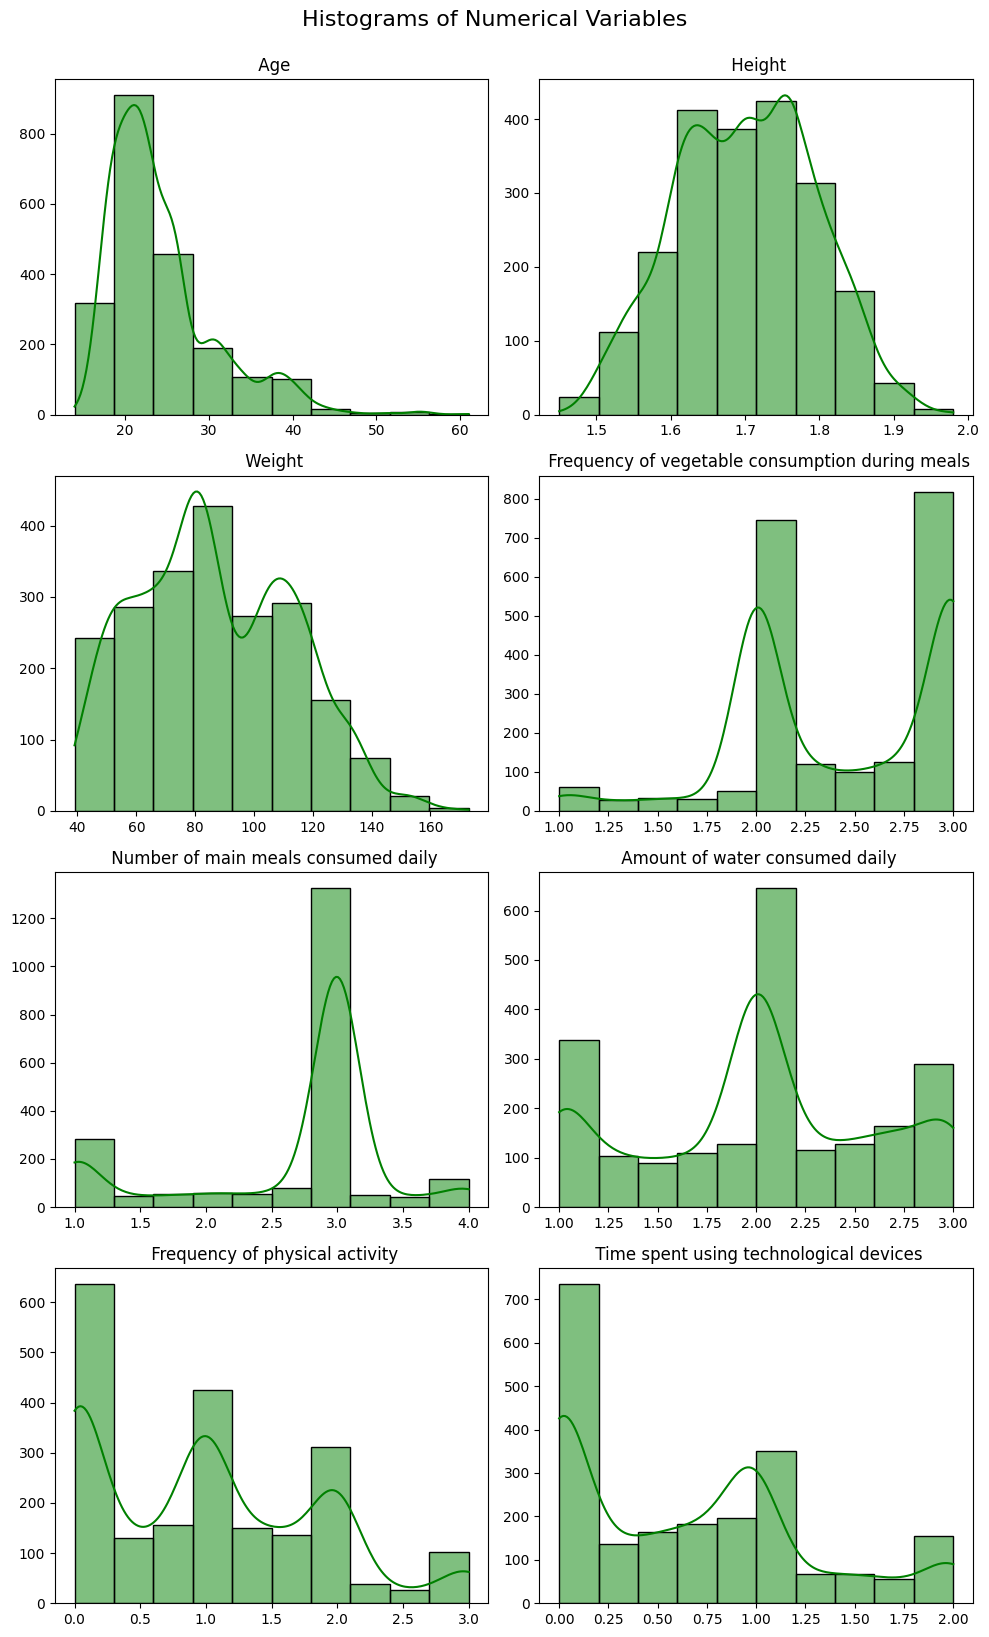

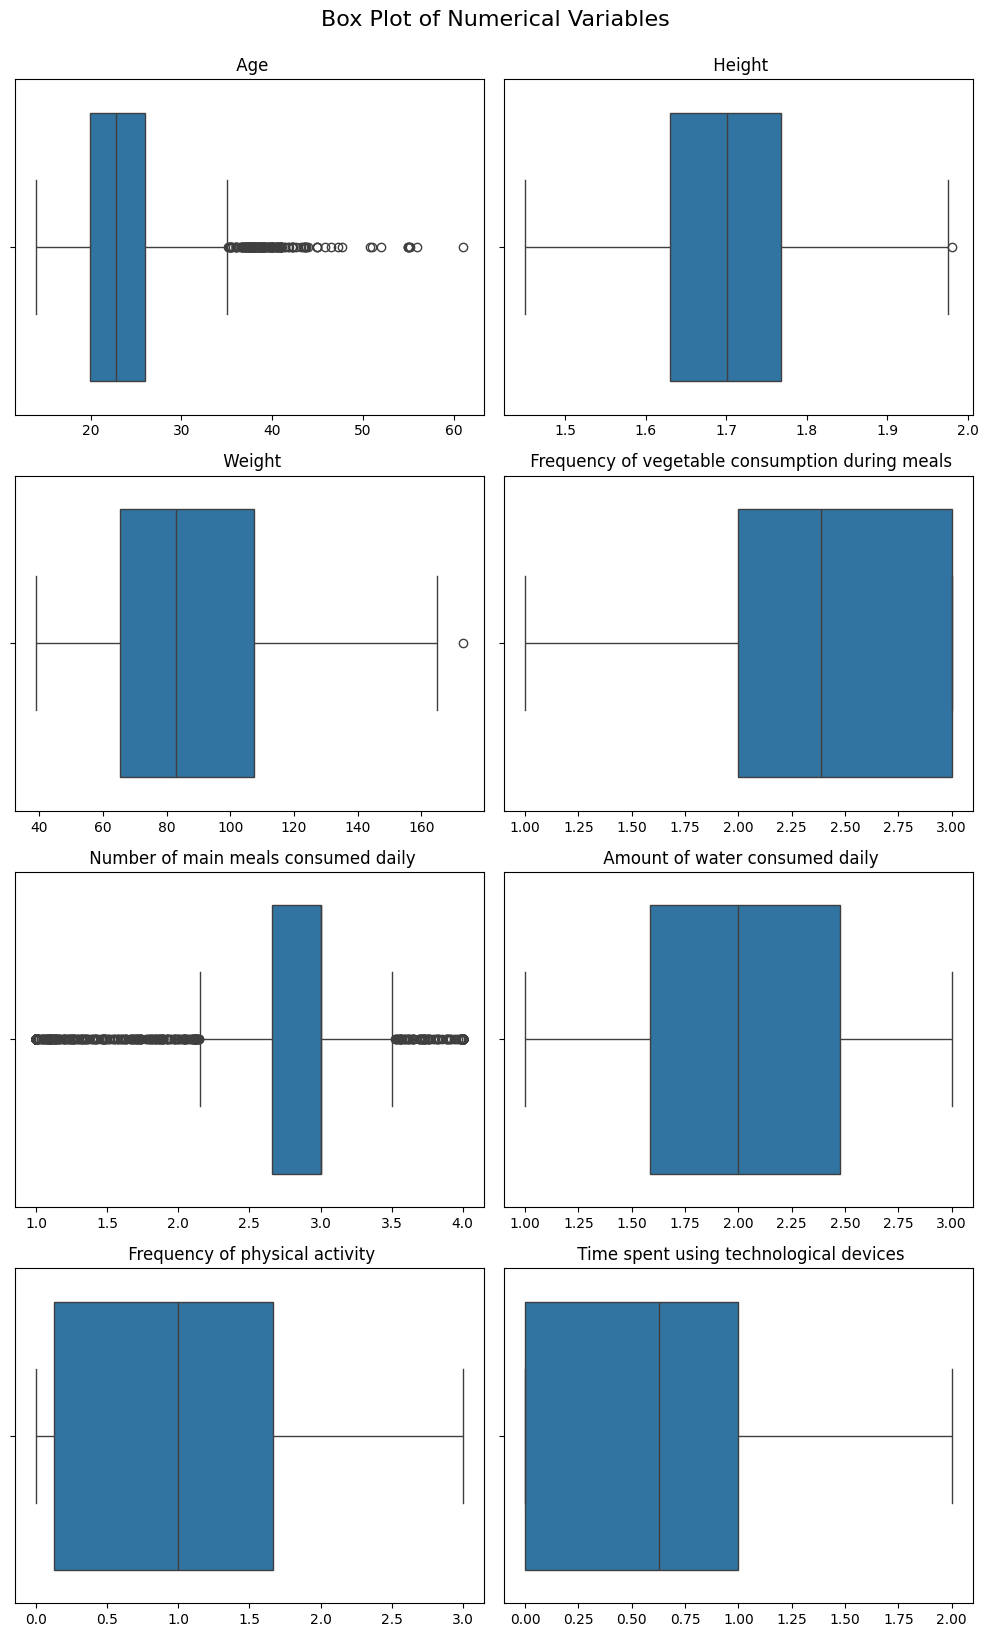

In [5]:
numericColumnsPlot(df, 2)
numericColumnsPlot(df, 2, BOX_PLOT)


<Axes: >

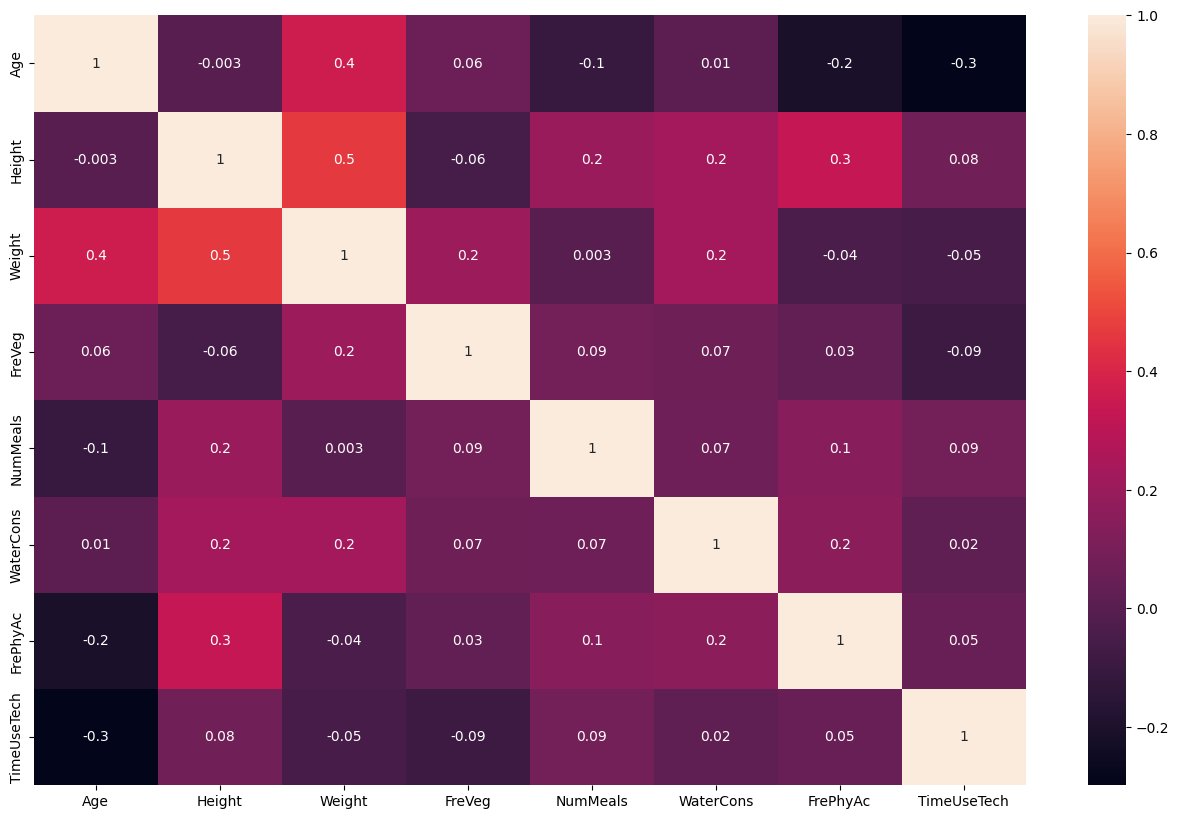

In [6]:
df_corr = df.corr(method = 'spearman', numeric_only=True)
figure = plt.figure(figsize=(16,10))
sns.heatmap(df_corr, annot=True, fmt = '.1g')

<div class="alert alert-block alert-warning">

<a id='incons'></a>

## 2.3. Possible inconsistencies
    
</div>

In [7]:
print("\nTesting Possible inconsistency: someone that drinks Frequently and is under 19")
PossInconsist=df.query("FreAlcCons=='Frequently' & Age < 19")
display(PossInconsist)

print("\nTesting Possible inconsistency: someone that drinks Sometimes and is under 17")
PossInconsist=df.query("FreAlcCons=='Sometimes' & Age < 17")
display(PossInconsist)

print("\nTesting Possible inconsistency: : someone that smoke and is under 19")
PossInconsist=df.query("Smoke=='yes' & Age < 19")
display(PossInconsist)



Testing Possible inconsistency: someone that drinks Frequently and is under 19


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,NObeyesdad
125,Male,18.000000,1.750000,80.000000,yes,yes,2.000000,3.000000,Always,no,2.000000,no,0.000000,0.000000,Frequently,Public_Transportation,Overweight_Level_I
298,Male,18.000000,1.800000,80.000000,yes,yes,2.000000,3.000000,Frequently,no,1.000000,no,0.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
334,Female,18.000000,1.450000,53.000000,no,yes,2.000000,3.000000,Frequently,no,2.000000,yes,1.000000,2.000000,Frequently,Public_Transportation,Overweight_Level_I
417,Male,18.000000,1.770000,87.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.000000,no,1.000000,1.000000,Frequently,Public_Transportation,Overweight_Level_II
436,Female,18.000000,1.560000,55.000000,no,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Frequently,Automobile,Normal_Weight
754,Female,18.836315,1.751631,80.000000,yes,yes,2.000000,1.737620,Sometimes,no,2.207978,no,2.641072,0.707044,Frequently,Public_Transportation,Overweight_Level_I
801,Female,18.270434,1.737165,76.699774,yes,yes,2.838969,3.000000,Sometimes,no,2.425927,no,1.000000,1.453335,Frequently,Public_Transportation,Overweight_Level_I
818,Male,18.900253,1.750359,79.828725,yes,yes,2.000000,2.228113,Sometimes,no,2.045004,no,1.293665,0.961806,Frequently,Public_Transportation,Overweight_Level_I
889,Female,18.869151,1.756774,79.989789,yes,yes,2.000000,2.658639,Sometimes,no,2.781628,no,1.955992,1.409198,Frequently,Public_Transportation,Overweight_Level_I
969,Male,18.014333,1.751029,80.000000,yes,yes,2.000000,2.805436,Sometimes,no,2.122884,no,0.045651,0.017225,Frequently,Public_Transportation,Overweight_Level_I



Testing Possible inconsistency: someone that drinks Sometimes and is under 17


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,NObeyesdad
290,Male,16.000000,1.820000,71.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
302,Male,16.000000,1.840000,45.000000,yes,yes,3.000000,3.000000,Always,no,3.000000,no,3.000000,2.000000,Sometimes,Walking,Insufficient_Weight
303,Female,16.000000,1.570000,49.000000,no,yes,2.000000,4.000000,Always,no,2.000000,no,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
553,Male,16.306870,1.752755,50.000000,no,yes,2.310423,3.558637,Sometimes,no,1.787843,no,1.926592,0.828549,Sometimes,Public_Transportation,Insufficient_Weight
554,Male,16.198153,1.691007,52.629374,no,yes,2.000000,2.000986,Sometimes,no,2.673835,no,0.992950,0.474836,Sometimes,Public_Transportation,Insufficient_Weight
563,Female,16.270434,1.818268,47.124717,no,yes,3.000000,3.286431,Sometimes,no,2.148146,no,2.458237,1.273333,Sometimes,Public_Transportation,Insufficient_Weight
624,Male,16.496978,1.691206,50.000000,no,yes,2.000000,1.630846,Sometimes,no,2.975528,no,0.548991,0.369134,Sometimes,Public_Transportation,Insufficient_Weight
627,Female,16.611837,1.830068,43.534531,no,yes,2.945967,3.000000,Sometimes,no,2.953192,no,2.830911,1.466667,Sometimes,Public_Transportation,Insufficient_Weight
689,Female,16.834813,1.744020,50.000000,no,yes,2.190050,3.420618,Sometimes,no,1.356405,no,1.351996,0.984680,Sometimes,Public_Transportation,Insufficient_Weight
698,Female,16.613108,1.777929,44.762023,no,yes,2.911877,3.098399,Sometimes,no,2.196405,no,2.328147,1.550110,Sometimes,Public_Transportation,Insufficient_Weight



Testing Possible inconsistency: : someone that smoke and is under 19


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,NObeyesdad
294,Male,18.0,1.86,110.0,yes,yes,2.0,1.0,Sometimes,yes,2.0,no,1.0,2.0,Sometimes,Public_Transportation,Obesity_Type_I


These results don’t show nothing too strange.

<div class="alert alert-block alert-warning">

<a id='stats'></a>

## 2.4. Statistical Exploration
    
</div>

<div class="alert alert-block alert-info">
    
<a id='stats_num'></a>

### 2.4.1. Numerical Variables
    
</div>

In [8]:
print("\n Describe numerical variables")
numVar=df.describe().T
display(numVar)


 Describe numerical variables


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FreVeg,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NumMeals,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
WaterCons,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FrePhyAc,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TimeUseTech,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


From the above table, we can get these conclusions:
- `count`- All variable have 2111 values. So no missing values.
- `weight`
  - `mean`- The mean weight is 86.58kg.
  - `50%`- Half of the population analysed has 83kg
  - `max`- And the max is 173kg. (Not sure if this value is an outlier.)
- `min`- The minimum time of technology used is 0. Not sure if it's valid.
- `max`- The age group is between 14 and 61 years old.

We can also analyse:
- skewness
- kurtosis.
- And see relation between people who monitor calories intake with accuracy vegatables intake.

<div class="alert alert-block alert-info">
    
<a id='stats_cat'></a>

### 2.4.2. Categorical Variables
    
</div>

Getting the main descriptive statistics for all the categorical variables

In [9]:
print("\n Describe categorical variables")
df.describe(include = ['O'])


 Describe categorical variables


,Gender,FamHist,FreHighCal,FreBeweenMeals,Smoke,MonitorDailyCal,FreAlcCons,MTransp,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


Should we drop these variables?
- `Smoke` - Has only 44 people.
- `MonitorDailyCal` Has only 96 values.

`Public_Transportation` Has the majority of the values for mode of Transportation.

These columns have binaries types but are encoded as object: ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

**Converting from `object` to `int` datatype:** (`0` and `1` values):

In [10]:
# Initialize df_bin as a copy of df to store binary encoded columns
df_bin = df.copy()

# Encoding binary categorical columns
df_bin['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df_bin['FamHist'] = df['FamHist'].map({'no': 0, 'yes': 1})
df_bin['FreHighCal'] = df['FreHighCal'].map({'no': 0, 'yes': 1})
df_bin['Smoke'] = df['Smoke'].map({'no': 0, 'yes': 1})
df_bin['MonitorDailyCal'] = df['MonitorDailyCal'].map({'no': 0, 'yes': 1})

# List of binary columns to convert to integer type
binary_cols = ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

# Convert the specified binary columns to integer type in df_bin
for col in binary_cols:
    df_bin[col] = df_bin[col].astype(int)
display(df_bin.info())

print("DataFrame after encoding binary columns:")
display(df_bin.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2111 non-null   int64  
 1   Age              2111 non-null   float64
 2   Height           2111 non-null   float64
 3   Weight           2111 non-null   float64
 4   FamHist          2111 non-null   int64  
 5   FreHighCal       2111 non-null   int64  
 6   FreVeg           2111 non-null   float64
 7   NumMeals         2111 non-null   float64
 8   FreBeweenMeals   2111 non-null   object 
 9   Smoke            2111 non-null   int64  
 10  WaterCons        2111 non-null   float64
 11  MonitorDailyCal  2111 non-null   int64  
 12  FrePhyAc         2111 non-null   float64
 13  TimeUseTech      2111 non-null   float64
 14  FreAlcCons       2111 non-null   object 
 15  MTransp          2111 non-null   object 
 16  NObeyesdad       2111 non-null   object 
dtypes: float64(8),

None

DataFrame after encoding binary columns:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<div class="alert alert-block alert-info">
    
<a id='skew'></a>

### 2.4.3. Skewness and kurtosis
    
</div>

High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

High kurtosis in a data set is an indicator that data has heavy tails or outliers. A standard normal distribution has a kurtosis of 3, so values higher than that could indicate presence of outliers. We need to check further this variable about the presence of possible outliers.

In [11]:
df_bin.skew(numeric_only=True).sort_values()

,0
FreHighCal,-2.399125
FamHist,-1.646216
NumMeals,-1.107097
FreVeg,-0.432906
WaterCons,-0.104912
Gender,-0.023704
Height,-0.012855
Weight,0.255410
FrePhyAc,0.498490
TimeUseTech,0.618502


Concerning the variables' skewness, we can conclude the following:

*   **Highly Skewed (absolute value > 1.0):**
    *   `Smoke` (6.71): Very high positive skewness, indicating a large number of 'no' responses and few 'yes' responses.
    *   `MonitorDailyCal` (4.37): High positive skewness, suggesting most individuals do not monitor daily calorie intake.
    *   `Age` (1.53): High positive skewness, meaning there are more younger individuals and fewer older ones.
    *   `NumMeals` (-1.11): High negative skewness.
    *   `FamHist` (-1.65): High negative skewness, suggesting most individuals have a family history with overweight.
    *   `FreHighCal` (-2.40): Very high negative skewness, indicating that the majority frequently consume high-calorie food.

*   **Moderately Skewed (absolute value between 0.5 and 1.0):**
    *   `TimeUseTech` (0.62): Shows moderate positive skewness.

*   **Slightly Skewed or Approximately Symmetrical (absolute value < 0.5):**
    *   `FrePhyAc` (0.50), `Weight` (0.26), `Gender` (-0.02), `Height` (-0.01), `WaterCons` (-0.10), `FreVeg` (-0.43). These variables are relatively symmetrically distributed or have very mild skewness.

High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

In [12]:
df_bin.kurt(numeric_only=True).sort_values()

,0
Gender,-2.001335
WaterCons,-0.879395
Weight,-0.699898
FreVeg,-0.637546
FrePhyAc,-0.620588
Height,-0.562949
TimeUseTech,-0.548660
NumMeals,0.385527
FamHist,0.710699
Age,2.826389


The kurtosis values provide insights into the 'tailedness' of each variable's distribution. Here's a breakdown of what these results suggest:

*   **Highly Leptokurtic (Kurtosis > 1, indicating heavy tails and potential for more outliers):**
    *   `Smoke` (43.10): This is an extremely high kurtosis, confirming that 'Smoke' is a highly concentrated variable with very few 'yes' values, leading to a very peaked distribution with heavy tails relative to a normal distribution. This is consistent with its high skewness.
    *   `MonitorDailyCal` (17.08): A very high kurtosis suggests that the distribution for 'MonitorDailyCal' is very peaked with heavy tails, implying a large number of values clustered at one end and a few extreme values.
    *   `FreHighCal` (3.76): Shows a notable leptokurtic distribution, indicating a more peaked distribution and heavier tails than a normal distribution.
    *   `Age` (2.83): Moderately leptokurtic, suggesting its distribution is slightly more peaked with somewhat heavier tails compared to a normal distribution.

*   **Platykurtic (Kurtosis < 0, indicating lighter tails and fewer outliers):**
    *   `Gender` (-2.00): As expected for a binary variable, it exhibits a very platykurtic distribution, which is flatter than a normal distribution and has no tails in the traditional sense.
    *   `WaterCons` (-0.88), `Weight` (-0.70), `FreVeg` (-0.64), `FrePhyAc` (-0.62), `Height` (-0.56), `TimeUseTech` (-0.55): These variables display platykurtic distributions. This means their distributions are flatter than a normal distribution, with lighter tails and fewer extreme values (outliers).

*   **Mesokurtic/Slightly Leptokurtic (Kurtosis closer to 0 or slightly positive, similar to a normal distribution in terms of tailedness):**
    *   `NumMeals` (0.39), `FamHist` (0.71): These variables have kurtosis values closer to zero, suggesting their distributions are somewhat similar to a normal distribution in terms of tailedness, or are only slightly more peaked with slightly heavier tails.

<div class="alert alert-block alert-info">
    
<a id='cat'></a>

### 2.4.3. Remaining Categorical Variables
    
</div>

Getting more descriptive statistics of the remaining categorical variables after transforming the binary ones into numeric.

In [13]:
# Show counts for categorical features
for column in df_bin.select_dtypes(include='object').columns:
    print("\n", df_bin[column].value_counts())


 FreBeweenMeals
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

 FreAlcCons
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

 MTransp
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


The `value_counts()` output for the remaining categorical features (`FreBeweenMeals`, `FreAlcCons`, and `MTransp`) shows the following:

*   **`FreBeweenMeals` (Frequency of food consumption between meals):**
    *   The vast majority of individuals (`1765`) consume food **'Sometimes'** between meals.
    *   A smaller group (`242`) does so **'Frequently'**.
    *   Very few (`53`) consume food **'Always'** between meals, and an even smaller number (`51`) **'no'** food between meals.

*   **`FreAlcCons` (Frequency of alcohol consumption):**
    *   Most individuals (`1401`) consume alcohol **'Sometimes'**.
    *   A significant portion (`639`) consume **'no'** alcohol.
    *   Only a small number (`70`) consume alcohol **'Frequently'**.
    *   Only `1` individual consumes alcohol **'Always'**, which was identified as a potential outlier earlier.

*   **`MTransp` (Primary mode of transportation used):**
    *   The overwhelming majority (`1580`) use **'Public_Transportation'**.
    *   **'Automobile'** is the second most common mode (`457`).
    *   **'Walking'** is used by a much smaller group (`56`).
    *   **'Motorbike'** (`11`) and **'Bike'** (`7`) are very rarely used, suggesting these categories might have limited predictive power due to their low frequency.

We'll Replace `Always` with `Frequently` in  the `FreAlcCons` feature which might be an outlier.

In [14]:
# Initialize df_normalized to store the changed value for the possible outlier
df_normalized = df_bin.copy()
df_normalized['FreAlcCons'] = df_bin['FreAlcCons'].replace('Always', 'Frequently')

print("Value counts for 'FreAlcCons' after replacement:")
print(df_normalized['FreAlcCons'].value_counts())


Value counts for 'FreAlcCons' after replacement:
FreAlcCons
Sometimes     1401
no             639
Frequently      71
Name: count, dtype: int64


<div class="alert alert-block alert-info">
    
<a id='target'></a>

### 2.4.5. Target Variable
    
</div>

For the target variable `NObeyesdad`, we'll apply ordinal encoding to maintain the order of obesity levels. And rename it to `TargetObesityL`

In [15]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order of the obesity levels
obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

df_clean = df_normalized.copy()
# Initialize the OrdinalEncoder with the specified categories
encoder = OrdinalEncoder(categories=[obesity_order])

# Apply ordinal encoding to the 'NObeyesdad' column
df_clean['TargetObesityL'] = encoder.fit_transform(df_clean[['NObeyesdad']])

# Drop the original 'NObeyesdad' column if desired, or keep both
df_clean = df_clean.drop(columns=['NObeyesdad'])

print("\nDataFrame after ordinal encoding 'NObeyesdad':")
display(df_clean.head())
print("\nUnique encoded values for 'TargetObesityL':")
print(df_clean['TargetObesityL'].value_counts())



DataFrame after ordinal encoding 'NObeyesdad':


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,1.0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,1.0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,1.0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,2.0
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,3.0



Unique encoded values for 'TargetObesityL':
TargetObesityL
4.0    351
6.0    324
5.0    297
2.0    290
3.0    290
1.0    287
0.0    272
Name: count, dtype: int64


<div class="alert alert-block alert-warning">

<a id='visual'></a>

## 2.5. Visual Exploration
    
</div>    

<div class="alert alert-block alert-info">
    
<a id='visual_num'></a>

### 2.5.1. Numerical Variables
    
</div>

Checking the distribution of the numeric variables using a `histplot()`. Define the color as green and the number of bins equal to 10.


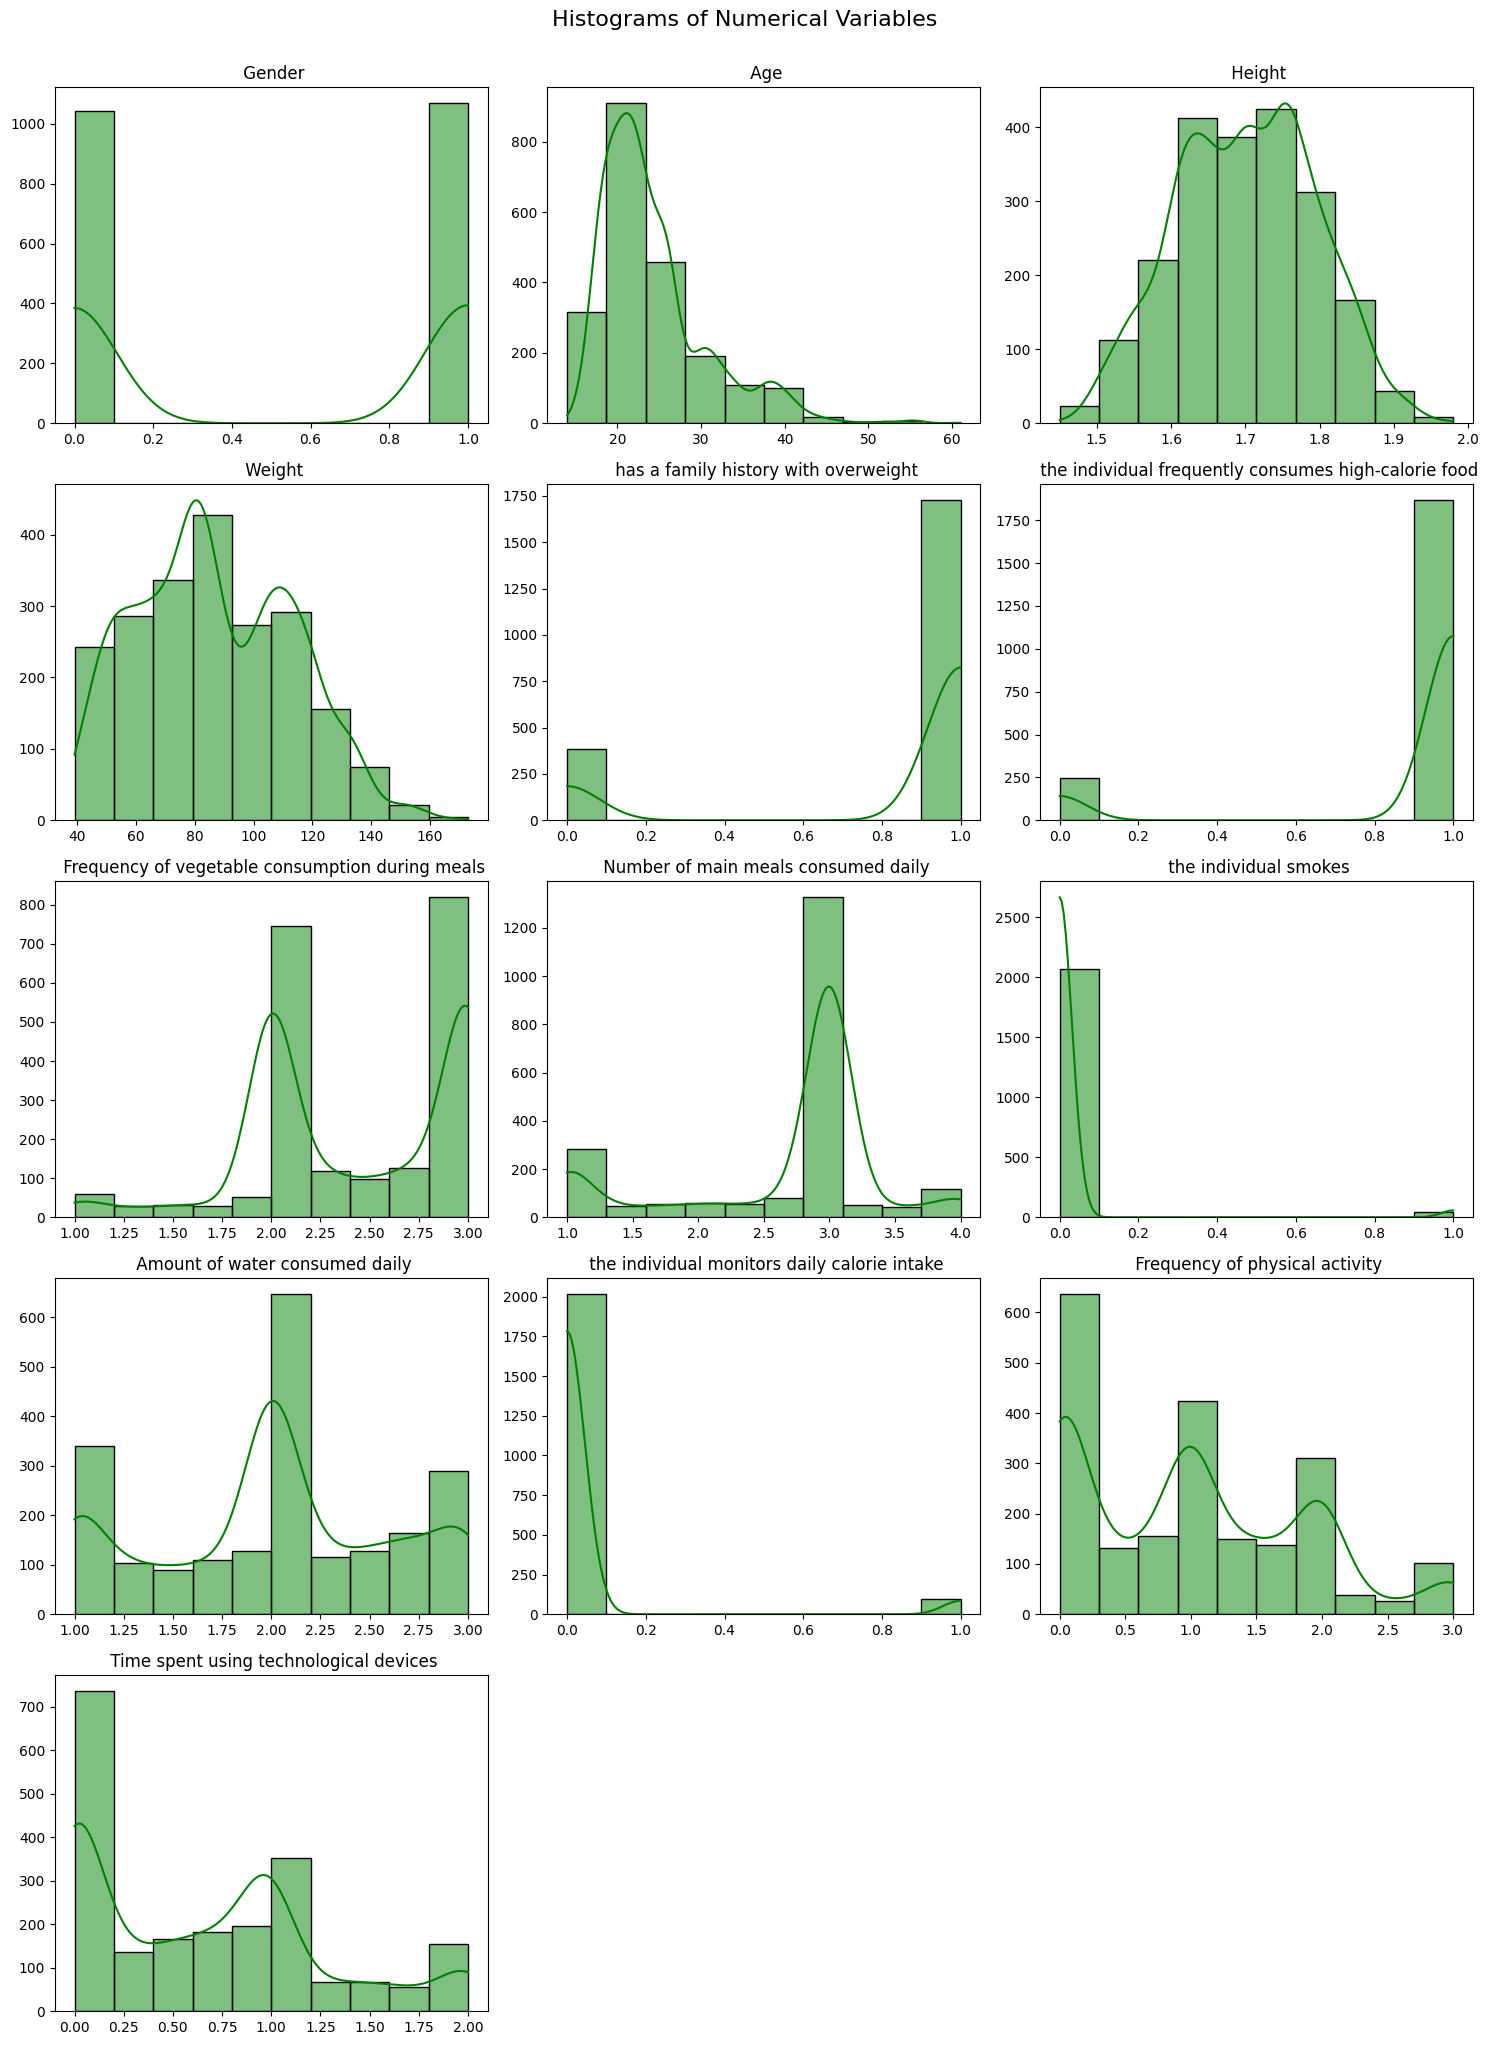

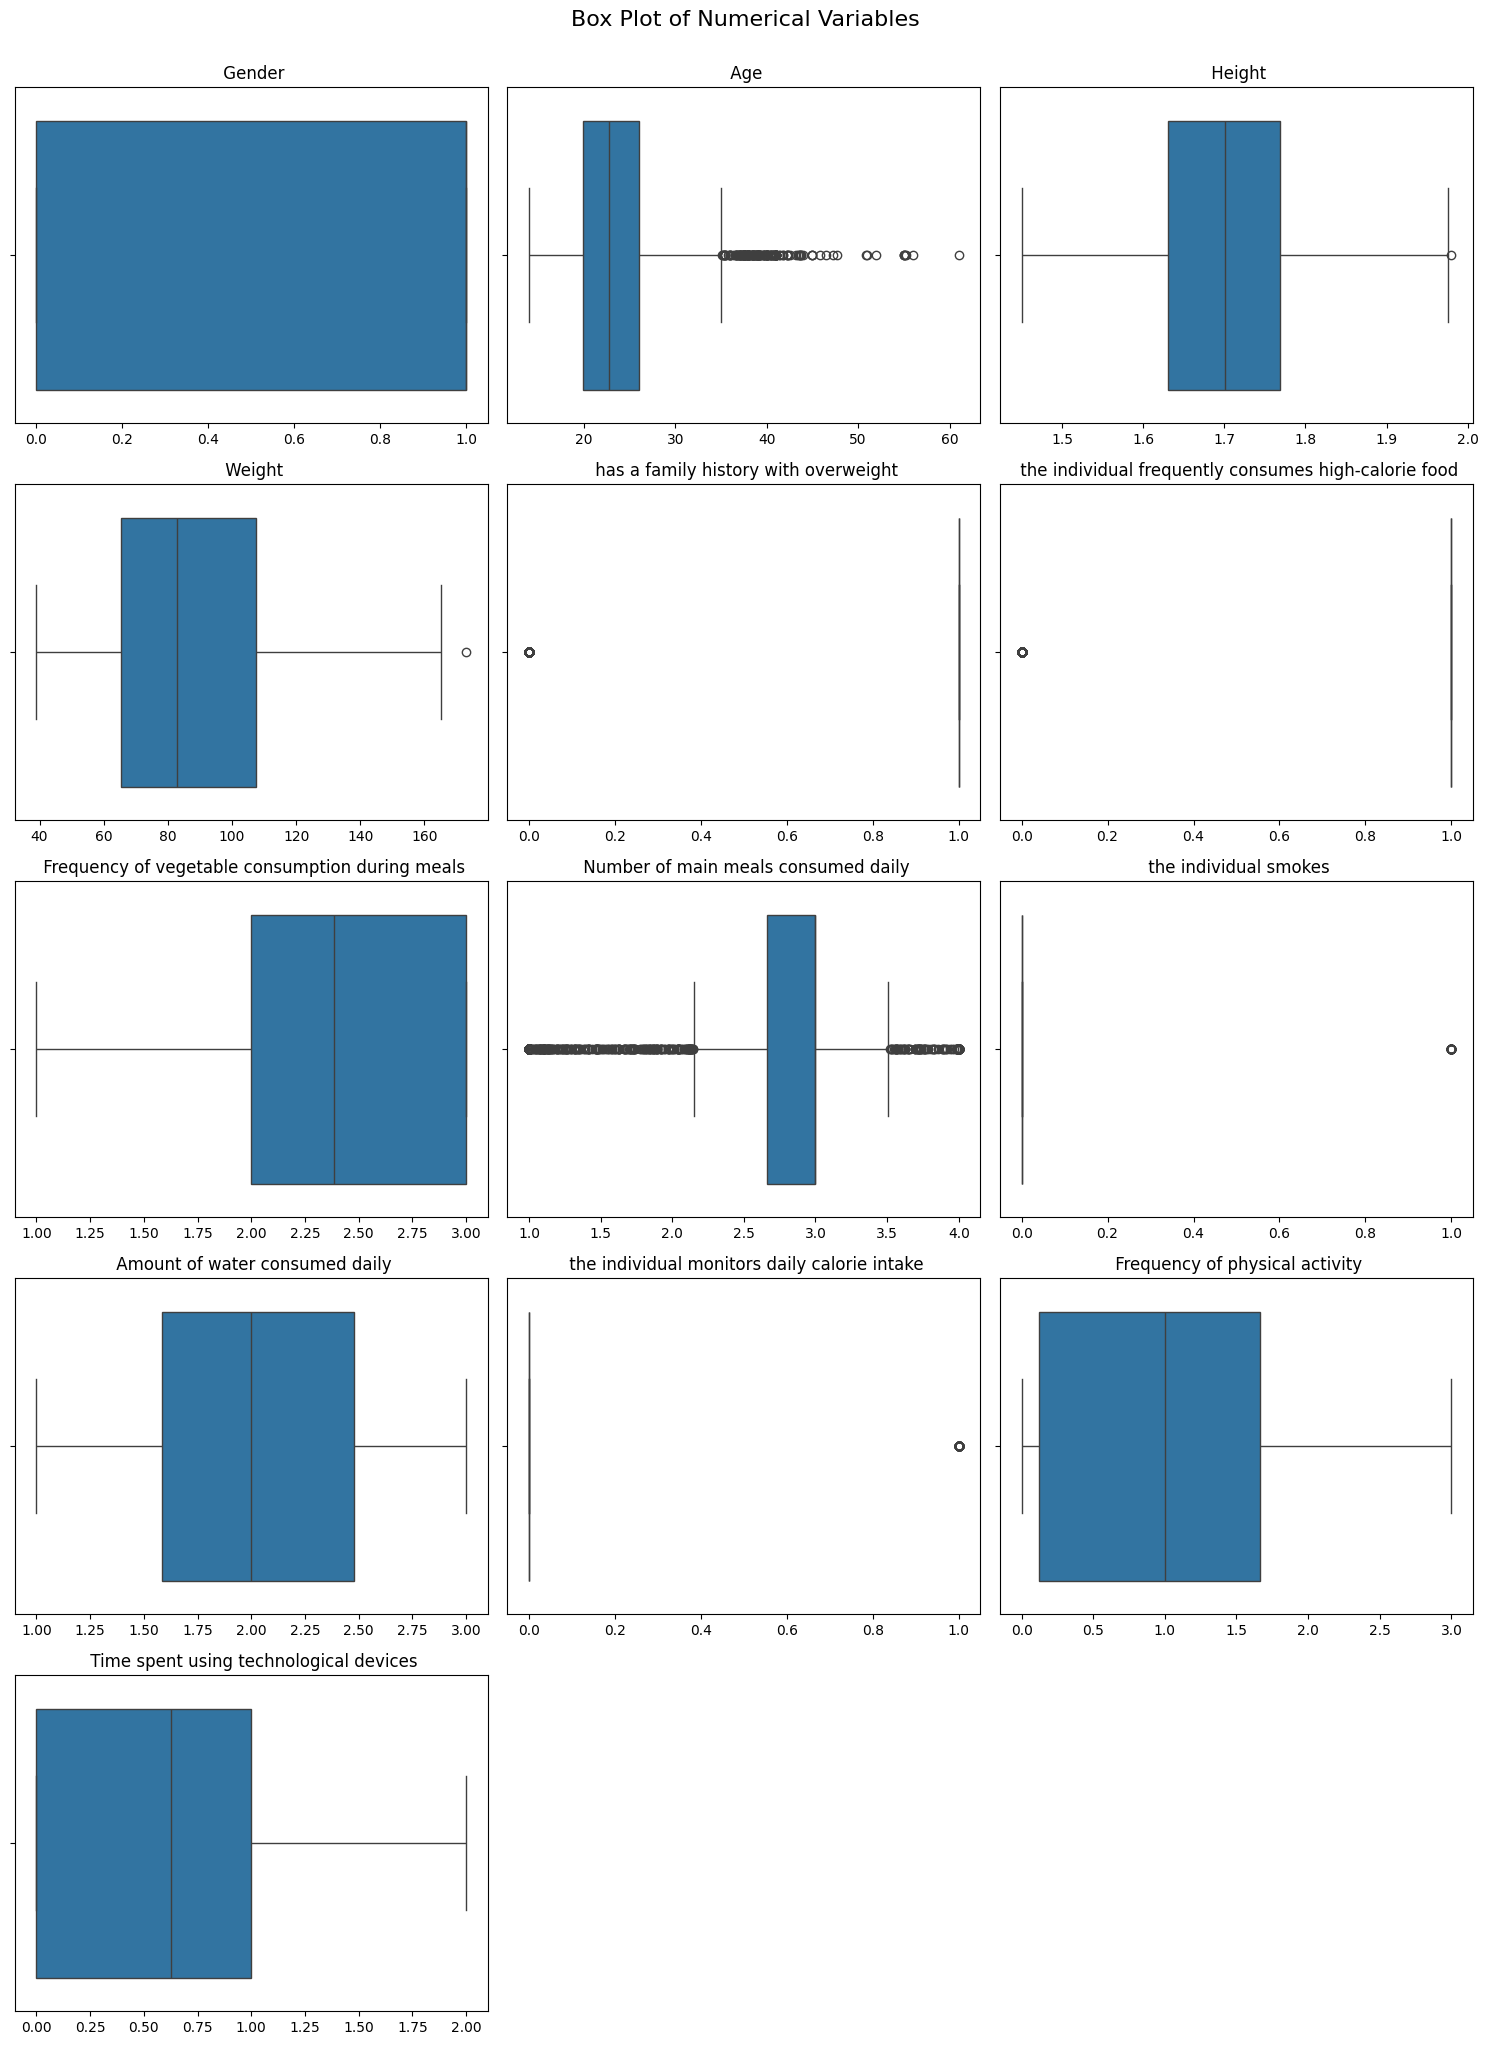

In [16]:
numericColumnsPlot(df_clean, 3)
numericColumnsPlot(df_clean, 3, BOX_PLOT )

<Axes: >

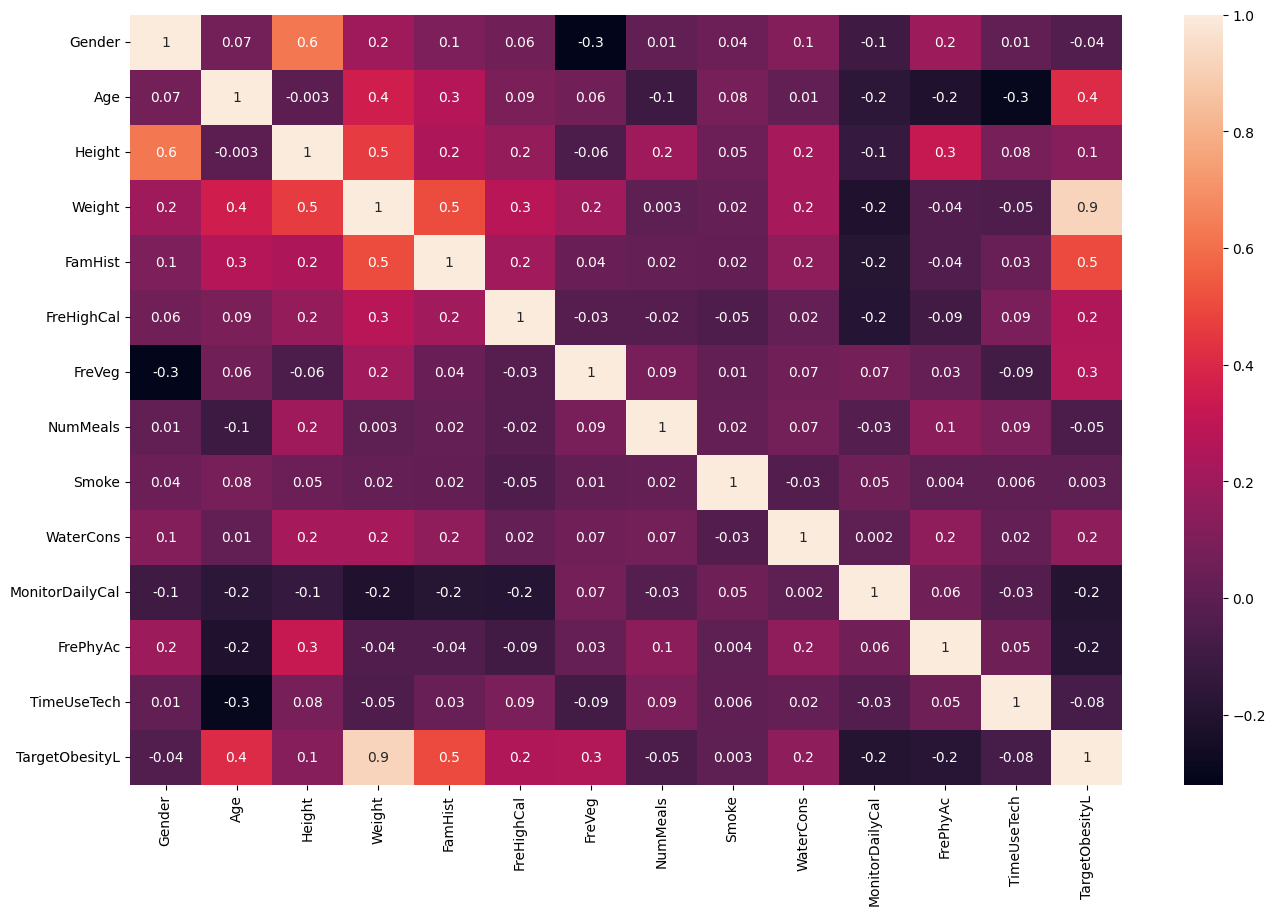

In [26]:
df_corr = df_clean.corr(method = 'spearman', numeric_only=True)
figure = plt.figure(figsize=(16,10))
sns.heatmap(df_corr, annot=True, fmt = '.1g')

<div class="alert alert-block alert-info">
    
<a id='cat_num'></a>

### 2.5.2. Categorical Variables
    
</div>

Checking the distribution of the numeric variables using a `histplot()`. Define the color as green and the number of bins equal to 10.


In [17]:
print(df_clean.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBeweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'TargetObesityL'],
      dtype='object')


Text(0, 0.5, '')

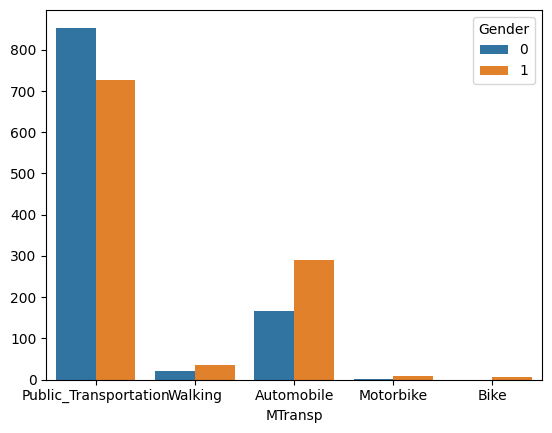

In [18]:
# sns.countplot(x = 'TargetObesityL', hue = 'Age', data = df_clean)
# plt.ylabel('')

sns.countplot(x = 'MTransp', hue = 'Gender', data = df_clean)
plt.ylabel('')

# sns.countplot(x = 'MTransp', hue = 'TargetObesityL', data = df_clean)
# plt.ylabel('')

### 1.3.Feature Scaling and Transformation

### 1.4 Identifying Outliers (using IQR method)

1.4.1 We will identify outliers in the numerical columns using the Interquartile Range (IQR) method.
This involves calculating the first quartile (Q1), third quartile (Q3), and the IQR for each numerical feature, and then defining upper and lower bounds to detect any values falling outside these ranges.

1.4.1 Use graphical methods (histograms,
scatterplots...), or statistical methods
(Z - score, Isolation Forests...)

In [19]:
import numpy as np

# Identify numerical columns for outlier detection (excluding one-hot encoded and target variable)
# We'll use the 'numerical_cols' list from the previous scaling step, as it contains only original numerical features

print("Identifying outliers using the IQR method:")

outlier_summary = {} # Dictionary to store outlier counts

# Define numeric_columns here
numeric_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'TargetObesityL' in numeric_columns:
    numeric_columns.remove('TargetObesityL')

for col in numeric_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    # Store the count of outliers
    outlier_summary[col] = len(outliers)

    if not outliers.empty:
        print(f"\nColumn '{col}': {len(outliers)} outliers detected (min: {outliers[col].min()}, max: {outliers[col].max()})")
        # if len(outliers) < 3:
        display(outliers[[col]].head())

print("\nSummary of Outliers Detected:")
for col, count in outlier_summary.items():
   if count > 0: print(f"'{col}': {count} outliers")

Identifying outliers using the IQR method:

Column 'Age': 168 outliers detected (min: 35.125401, max: 61.0)


,Age
13,41.0
21,52.0
33,39.0
92,55.0
104,38.0



Column 'Height': 1 outliers detected (min: 1.98, max: 1.98)


,Height
349,1.98



Column 'Weight': 1 outliers detected (min: 173.0, max: 173.0)


...


Column 'Smoke': 44 outliers detected (min: 1, max: 1)


,Smoke
1,1
18,1
21,1
25,1
43,1



Column 'MonitorDailyCal': 96 outliers detected (min: 1, max: 1)


,MonitorDailyCal
1,1
11,1
15,1
28,1
36,1



Summary of Outliers Detected:
'Age': 168 outliers
'Height': 1 outliers
'Weight': 1 outliers
'FamHist': 385 outliers
'FreHighCal': 245 outliers
'NumMeals': 579 outliers
'Smoke': 44 outliers
'MonitorDailyCal': 96 outliers


##Data Cleaning – Outliers

### Remove
*   Only the most extreme ones.
* Rule of thumb: No more than 3% of your data. If more, try the other
approaches to the less extreme outliers.

### Clipping
* Clip Feature values between lower bound and upper bound.
* We can choose these lower bound and upper bound values using the percentile
of the feature (for example 1st and 99th percentile)

###Assign a new value
If an outlier seems to be due to a mistake in your data, try imputing a value (mean / median / predictive model ...)

###Transform
Create a percentile version of your original field and working with that new field instead.


2.  Use one-hot encoding for 'FreBeweenMeals', 'FreAlcCons' and 'MTransp'

In [20]:
# One-hot encoding for multi-category nominal features
nominal_cols = ['FreBeweenMeals', 'FreAlcCons', 'MTransp']
df_hot = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

print("\nDataFrame after one-hot encoding:")
display(df_hot.head())



DataFrame after one-hot encoding:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,Smoke,WaterCons,...,TargetObesityL,FreBeweenMeals_Frequently,FreBeweenMeals_Sometimes,FreBeweenMeals_no,FreAlcCons_Sometimes,FreAlcCons_no,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,...,1.0,0,1,0,0,1,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,...,1.0,0,1,0,1,0,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,...,1.0,0,1,0,0,0,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,...,2.0,0,1,0,0,0,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,...,3.0,0,1,0,1,0,0,0,1,0


In [21]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_clean.copy()

# Identify numerical columns for scaling (excluding the encoded target variable)
numerical_cols = df_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('TargetObesityL') # Exclude the target variable from scaling

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("\nDataFrame after feature scaling:")
display(df_scaled.head())



DataFrame after feature scaling:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBeweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,Sometimes,-0.145900,-0.013073,-0.218272,-1.188039,0.561997,no,Public_Transportation,1.0
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,Sometimes,6.853997,1.618759,4.581439,2.339750,-1.080625,Sometimes,Public_Transportation,1.0
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,Sometimes,-0.145900,-0.013073,-0.218272,1.163820,0.561997,Frequently,Public_Transportation,1.0
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,Sometimes,-0.145900,-0.013073,-0.218272,1.163820,-1.080625,Frequently,Walking,2.0
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,Sometimes,-0.145900,-0.013073,-0.218272,-1.188039,-1.080625,Sometimes,Public_Transportation,3.0


# **2. Additional Insights**

# 2.1  Do physical activity levels significantly influence obesity classification?


FAF  **Cont** - Frequency of physical activity

---
# 2.2  Are eating habits stronger predictors of obesity than demographic factors?


FAVC **Bin** -Indicates whether the individual frequently consumes high-calorie food

FCVC -**Int** -Frequency of vegetable consumption during meals

NCP - **Cont** Number of main meals consumed daily

CAEC **Cat** -Frequency of food consumption
between meals

SMOKE  **Bin** - Indicates whether the individual smokes

CH2O - **Cont** - Amount of water consumed daily

SCC **Bin** - Indicates whether the individual monitors daily calorie intake


CALC **Cat** - Frequency of alcohol consumption

---
2.3  Is there a relationship between technology usage (screen time) and obesity levels?


TUE **Int** - Time spent using technological devices (e.g., smartphone, computer, television, videogames)

---
2.4  Do transportation habits correlate with healthier lifestyles?

MTRANS **Cat** - Primary mode of transportation used

---
2.5  Can obesity patterns vary across age groups or genders?

Gender  **Cat** Gender of the individual

---
Age

Height




In [22]:
# MTRANS will be useful to the question: Do transportation habits correlate with healthier lifestyles?

In [23]:
#code here

**3. Predictive Modeling**

* Logistic Regression
* Decision Trees
* Random Forest
* Support Vector Machines
* K-Nearest Neighbors
* Gradient Boosting methods

**Students should:**

* Select relevant features
* Train and evaluate multiple models
* Compare model performance
* Apply hyperparameter tuning
* Interpreting the most important predictors


**Performance should be evaluated using appropriate metrics such as:**
* Accuracy
* Precision
* Recall

In [24]:
#code here

**NObeyesdad** represents the obesity classification of each individual.

The categories include:

* Insufficient Weight
* Normal Weight
* Overweight Level I
* Overweight Level II
* Obesity Type I
* Obesity Type II
* Obesity Type III

You will use this variable as the target variable for predictive modeling.